# Modelling infiltration into variably saturated, variably frozen soil

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.balanceChecks import soilBalanceCheck
from soilice.src_soil import model

In [3]:
from matplotlib.gridspec import GridSpec

In [4]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=0.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=True        # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=True   # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC
opts['groundHeatFlux']=0.        # 0. no specified ground heat flux; 1. use specified ground heat flux.

In [5]:
# Import soil parameters:
from soilice.pars_loam import pars

# Import constants:
from soilice.constants import const

# Convert parameter units into days:
pars['Ks']=pars['Ks']*86400
pars['kappa_org']=pars['kappa_org']*86400
pars['kappa_soil']=pars['kappa_soil']*86400
const['kappa_air']=const['kappa_air']*86400
const['kappa_ice']=const['kappa_ice']*86400
const['kappa_liq']=const['kappa_liq']*86400

In [6]:
# Space grid
zMax=2.
dz=0.01
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,20,0.1) # days
nt=len(t)
dt=t[1]-t[0]

In [7]:
# Boundary conditions - mass and heat fluxes:

# NOT USED:
TTop=np.zeros(nt)
TBot=np.zeros(nt)
jTopBC=np.zeros(nt)  # Specified ground heat flux, if used.

In [8]:
# # For a uniform simulation, just run this code unmodified. This is more efficient:
# parsD=MakeDictFloat()
# for k in pars: parsD[k]=pars[k]

# constD=MakeDictFloat()
# for k in const: constD[k]=const[k]

In [9]:
def irrigationPlot(t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title):
    i=np.arange(0,len(t),15)
    
    # --- Create figure and layout ---
    fig = pl.figure(figsize=(8,5))
    gs = GridSpec(3, 3, figure=fig)
    
    ax1 = fig.add_subplot(gs[0, :])
    ax2 = fig.add_subplot(gs[1:, 0])
    ax3 = fig.add_subplot(gs[1:, 1])
    ax4 = fig.add_subplot(gs[1:, 2])
    
    # --- Top plot (fluxes) ---
    ax1.plot(t, qT/dt*1000, 'r', lw=2, label='Infiltration')
    ax1.plot(t, qB/dt*1000, 'g', lw=2, label='Drainage')
    ax1.plot(t, qI*1000, 'b', label='Applied irrigation')
    ax1.set_ylim(0, 80)
    ax1.set_xlim(t[0], t[-1])     # 👈 fix: explicit x limits
    ax1.legend(loc=1)
    ax1.grid()
    ax1.set_ylabel("Flux (mm/d)")
    fig.suptitle(title)
    
    # --- Left plot (potentials) ---
    ax2.plot(psif[0,:].T, z, 'c', lw=2, label='Frozen potential')
    ax2.plot(psie[0,:].T, z, 'b', lw=2, label='Matric potential')
    ax2.plot(psif[i,:].T, z, 'c', lw=1)
    ax2.plot(psie[i,:].T, z, 'b', lw=1)
    # line_h, = ax2.plot([], z, 'g')
    ax2.set_ylim(2, 0)
    ax2.set_xlim(-6, 0)
    ax2.set_xlabel('Head (m)')
    ax2.set_ylabel('Depth (m)')
    ax2.legend(loc=3)
    ax2.grid()
    
    # --- Middle plot (water content) ---
    ax3.plot(thetaL[0,:].T, z, 'b', lw=2, label='Liquid')
    ax3.plot(thetaI[0,:].T, z, 'c', lw=2, label='Ice')
    ax3.plot(thetaL[i,:].T, z, 'b', lw=1)
    ax3.plot(thetaI[i,:].T, z, 'c', lw=1)
    ax3.set_ylim(2, 0)
    ax3.set_xlim(0, 0.5)
    ax3.set_yticklabels([])
    ax3.set_xlabel('Water content (-)')
    ax3.legend(loc=3)
    ax3.grid()
    
    # --- Right plot (temperature) ---
    ax4.plot(T[0,:].T, z, 'r', lw=2, label='Temperature')
    ax4.plot(T[i,:].T, z, 'r', lw=1)
    ax4.set_ylim(2, 0)
    ax4.set_xlim(-5.5,1.5)
    ax4.set_yticklabels([])
    ax4.set_xlabel('Temperature (°C)')
    ax4.grid()
    
    # --- Adjust spacing ---
    pl.subplots_adjust(wspace=0.05, hspace=0.4)

In [10]:
sim=model(opts,rtol=1e-8)
sim.setPars(pars)
sim.setConst(const)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(t[0],t[-1],t[1]-t[0])

ode, with jac runtime = 5.56 seconds


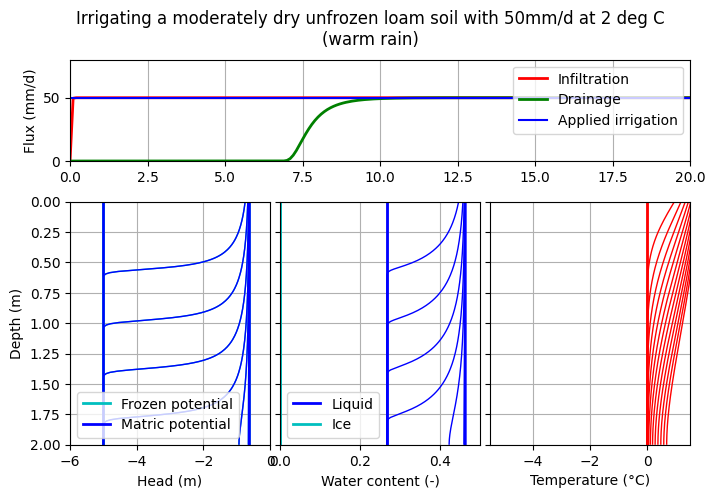

In [11]:
# Run scenarios with different initial conditions
# psi0=np.zeros(nz)-5 # z-zMax 
# T0=np.linspace(0,0,nz)
# qI=np.zeros(nt)+0.05
# TInf=np.zeros(nt)+2

qI=np.zeros(sim.nt)+0.05
sim.BCs(qI=qI,TInf=2)
sim.ICs(psi0=-5,T0=0)
out=sim.run()

t,z,psie,psif,T,thetaL,thetaI,qT,qB,jT,jB=(
    out.t,
    out.z,
    out.psie,
    out.psif,
    out.T,
    out.thetaL,
    out.thetaI,
    out.qT,
    out.qB,
    out.jT,
    out.jB
)

# run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,)

# psif=T*const['lambda_f']/(const['g']*const['T0'])
# psif[psif>0]=0.
# psif=np.minimum(psie,psif)
# h=np.array([psie[i,:]-z for i in range(nt)])

title=f"Irrigating a moderately dry unfrozen loam soil with 50mm/d at 2 deg C\n(warm rain)"
irrigationPlot(t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title)
pl.savefig('02_Irrigation01.png')

ode, with jac runtime = 2.07 seconds


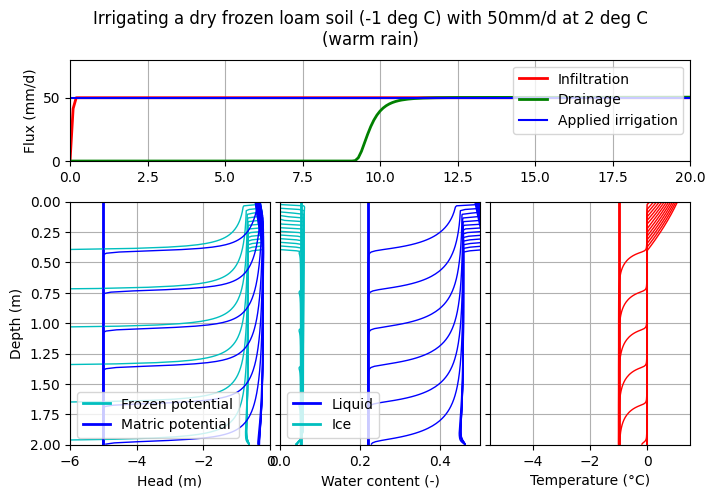

In [12]:
# Run scenarios with different initial conditions
qI=np.zeros(sim.nt)+0.05
sim.BCs(qI=qI,TInf=2)
sim.ICs(psi0=-5,T0=-1)
out=sim.run()

t,z,psie,psif,T,thetaL,thetaI,qT,qB,jT,jB=(
    out.t,
    out.z,
    out.psie,
    out.psif,
    out.T,
    out.thetaL,
    out.thetaI,
    out.qT,
    out.qB,
    out.jT,
    out.jB
)
title=f"Irrigating a dry frozen loam soil (-1 deg C) with 50mm/d at 2 deg C\n(warm rain)"
irrigationPlot(t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title)
pl.savefig('02_Irrigation02.png')

ode, with jac runtime = 1.07 seconds


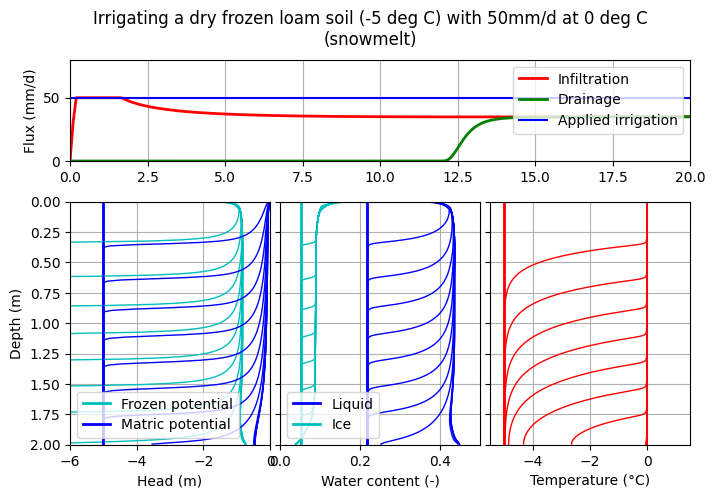

In [13]:
# Run scenarios with different initial conditions
qI=np.zeros(sim.nt)+0.05
sim.BCs(qI=qI,TInf=0)
sim.ICs(psi0=-5,T0=-5)
out=sim.run()

t,z,psie,psif,T,thetaL,thetaI,qT,qB,jT,jB=(
    out.t,
    out.z,
    out.psie,
    out.psif,
    out.T,
    out.thetaL,
    out.thetaI,
    out.qT,
    out.qB,
    out.jT,
    out.jB
)

title=f"Irrigating a dry frozen loam soil (-5 deg C) with 50mm/d at 0 deg C\n(snowmelt)"
irrigationPlot(t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title)
pl.savefig('02_Irrigation03.png')

ode, with jac runtime = 0.56 seconds


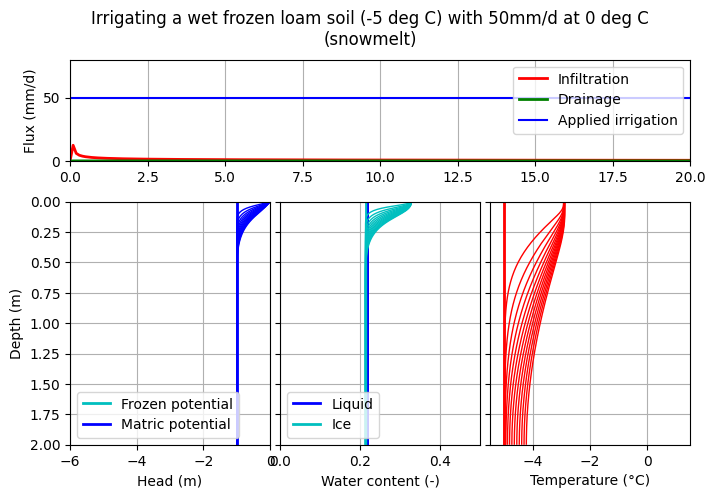

In [14]:
# Run scenarios with different initial conditions
qI=np.zeros(sim.nt)+0.05
sim.BCs(qI=qI,TInf=0)
sim.ICs(psi0=-1,T0=-5)
out=sim.run()

t,z,psie,psif,T,thetaL,thetaI,qT,qB,jT,jB=(
    out.t,
    out.z,
    out.psie,
    out.psif,
    out.T,
    out.thetaL,
    out.thetaI,
    out.qT,
    out.qB,
    out.jT,
    out.jB
)

title=f"Irrigating a wet frozen loam soil (-5 deg C) with 50mm/d at 0 deg C\n(snowmelt)"
irrigationPlot(t,qI,qT,qB,thetaL,thetaI,psie,psif,T,title)
pl.savefig('02_Irrigation04.png')